<h1>Part 2

In this part, we analyse the road network and road events (road accidents, marathons) in Leeds, UK.

Not all road accidents datasets have location coordinates so we will choose only the ones that do. Here we are considering the years 2011-2016.

<h2>Task A (Spatial Networks and Planarity)

In this task, we will construct and investigate a road network.  We are going to select an area of approximately 1 square kilometre around the centre of Leeds where at least 300 accidents occurred across multiple years. We will only consider roads used for driving, not walking paths or private roads.

In [3]:
import pandas as pd
from pyproj import Transformer
import osmnx as ox
from shapely.geometry import Polygon
import networkx as nx
import random
from geopy.distance import geodesic
import matplotlib.pyplot as plt

Importing road accidents datasets (2011-2016):

In [4]:
df2011=pd.read_csv("2011.csv",encoding='latin1')
df2012=pd.read_csv("2012.csv",encoding='latin1')
df2013=pd.read_csv("2013.csv",encoding='latin1')
df2014=pd.read_csv("2014.csv",encoding='latin1')
df2015=pd.read_csv("2015.csv",encoding='latin1')
df2016=pd.read_csv("2016.csv",encoding='latin1')

Pre-processing the datasets:
1. Remove whitespaces from column names
2. Rename location-related columns to 'Easting' and 'Northing' for consistency across all datasets
3. Concatenate the datasets
4. Drop missing values in the 'Easting' and 'Northing'


In [5]:
dfs = [df2011,df2012,df2013,df2014,df2015,df2016]
col_mapping={"Grid Ref: Easting": "Easting","Grid Ref: Northing": "Northing"}
for df in dfs: #remove whitespaces and rename columns for every dataframe
    df.columns=df.columns.str.strip()
    df.rename(columns=col_mapping,inplace=True)

df=pd.concat([df2011,df2012,df2013,df2014,df2015,df2016],ignore_index=True) #combine into one dataframe
df=df.dropna(subset=['Easting','Northing']) #dropping missing values in Easting and Northing columns
print("Total rows:",len(df))

Total rows: 15613


Therefore, between 2011 and 2016, there have been 15613 road accidents in Leeds.
Next we will convert Easting/Northing to Latitude/Longitude for OSMnx. We will use the pyproj library to carry out this transformation.

In [6]:
transformer1=Transformer.from_crs("EPSG:27700","EPSG:4326",always_xy=True) #easting/northing to lat/lon

df['Longitude'],df['Latitude']=transformer1.transform(df['Easting'].values,df['Northing'].values)

We will select a ~1 square km around central Leeds where 300 or more road accidents happened from 2011-2016.
What we did:
- get the latitude and longitude values of Leeds city centre (53.8008, -1.5491).
- transform those to Easting and Northing values (using Transformer function from pyproj library), and choose delta as 500 metres to define a square region of 1000m × 1000m (or 1 square km).
- count the number of accidents (2011–2016) to ensure at least 300 accidents occured within this area.

In [7]:
cen_lat=53.8008 #coordinates of center
cen_lon=-1.5491

transformer2=Transformer.from_crs("EPSG:4326","EPSG:27700",always_xy=True) #lat/lon to easting/northing
cen_east,cen_north=transformer2.transform(cen_lon,cen_lat)

delta = 500

area_df = df[
    (df['Easting']>=cen_east-delta)&
    (df['Easting']<=cen_east+delta)&
    (df['Northing']>=cen_north-delta)&
    (df['Northing']<=cen_north + delta)
]

print("Number of Accidents:",len(area_df))

Number of Accidents: 476


<h3>Question 1. What are the coordinates of the chosen area?

In [8]:
min_lat=area_df['Latitude'].min()
max_lat=area_df['Latitude'].max()
min_lon=area_df['Longitude'].min()
max_lon=area_df['Longitude'].max()
print (f'Latitude: [{min_lat}, {max_lat}]')
print(f'Longitude: [{min_lon}, {max_lon}]')

Latitude: [53.796346794120396, 53.80525933823592]
Longitude: [-1.5566665108403561, -1.5415365733771682]


The coordinates of the selected 1 km² area centred around Leeds city centre (latitude 53.8008 and longitude -1.5491) are:
- Latitude: [53.796346794120396, 53.80525933823592]
- Longitude: [-1.5566665108403561, -1.5415365733771682]

We will use a square polygon to extract the road network corresponding to the selected 1 km² area. This approach ensures precise control of the study region.

In [9]:
polygon=Polygon([(min_lon,min_lat),(min_lon,max_lat),(max_lon,max_lat),(max_lon,min_lat)])

G=ox.graph_from_polygon(polygon,network_type='drive')
print("Nodes:",len(G.nodes))
print("Edges:",len(G.edges))

Nodes: 127
Edges: 210


<h3>Question 2. What are the characteristics of this road network? Include, at least, the spatial diameter of the network, the average street length, node density, intersection density, and edge density.

**2.1 Average Street Length**<br>
The average street length reflects the typical size of road segments. The relatively small value indicates short road segments, which is characteristic of dense urban areas such as Leeds city centre.<br>
We use graph_to_gdfs(G,nodes=False) from OSMnx to turn the road network G and into a GeoDataFrame of edges. The parameter nodes=False ensures that we consider only the edges and not the nodes.

In [10]:
edges=ox.graph_to_gdfs(G,nodes=False)
avg_len=edges['length'].mean()
print("Average street length:",round(avg_len,3))

Average street length: 77.793


**2.2 Node Density**<br>
Node density is calculated as the number of nodes per unit area. Here, we have an area of 1 square km.

In [11]:
ar=1
n_density=len(G.nodes)/ar
print("Node density:",n_density)

Node density: 127.0


The node density is high, which means there are a large number of  intersections within a small area. This is common for a well-connected urban network.

**2.3 Intersection Density**<br>
An intersection is a node where 2 or more roads meet. Intersection density, therefore, is the number of such nodes in a given area.

In [12]:
inters=[n for n,d in G.degree() if d>=2]
inters_density=len(inters)/ar
print("Intersection density:",inters_density)

Intersection density: 120.0


A higher value means a complex street layout with many connection points.

**2.4 Edge Density**<br>
Edge density indicates the number of road segments within the area.

In [13]:
e_density=len(G.edges)/ar
print("Edge density:",e_density)

Edge density: 210.0


The high value confirms a dense and interconnected road structure.

**2.5 Spatial Diameter**<br>
The spatial diameter represents the longest shortest-path distance within the network. This reflects the maximum travel distance required between two points in the area using the road network.<br>
To calculate this, we need the network to be connected, so we find the largest connected component (LCC). Then we calculate the weighted shortest paths using all-pairs Dijkstra algorithm, and select the longest path from them as the spatial diameter of the road network.

In [14]:
lcc=max(nx.strongly_connected_components(G),key=len)
G_sub=G.subgraph(lcc).copy()

shortest_paths=dict(nx.all_pairs_dijkstra_path_length(G_sub,weight='length'))
sp_diam=max(max(d.values()) for d in shortest_paths.values())

print("Spatial diameter (meters):",sp_diam)

Spatial diameter (meters): 3118.836880931708


Therefore, the maximum travel distance between two points in the area using the road network is a little over 3km.

<h3>Question 3. What is the average circuitry of the network? What does this tell you about the efficiency of using roads in this area?

Circuitry is a ratio that measures how indirect travel (i.e. following the road network) is compared to straight-line (Euclidean) distance. A value greater than 1 indicates that routes are not perfectly direct. The analysis is performed on the largest connected component of the network to ensure that all nodes are reachable and shortest path distances are well-defined.<br>
For each unique pair in the road network, we calculate the:
- direct (Euclidean) distance between the nodes
- distance (shortest path) between the nodes following the road network
- ratio=network distance/euclidean distance<br>
Then we select the average of all the ratios as circuitry.

In [15]:
shortest_paths=dict(nx.all_pairs_dijkstra_path_length(G_sub,weight='length')) #network shortest paths between all pairs

def euclidean(n1,n2): #euclidean distance between 2 nodes in meters
    coords1=(G_sub.nodes[n1]['y'],G_sub.nodes[n1]['x'])
    coords2=(G_sub.nodes[n2]['y'],G_sub.nodes[n2]['x'])
    return geodesic(coords1,coords2).meters

nodes=list(G_sub.nodes)
ratios=[]

for n1 in nodes:
    for n2 in nodes:
        if n1!=n2:
            try:
                d_net=shortest_paths[n1][n2]
                d_euc=euclidean(n1,n2)
                if d_euc>0:
                    ratios.append(d_net/d_euc)
            except:
                pass

avg_circ=sum(ratios)/len(ratios)
print("Average Circuitry:",avg_circ)

Average Circuitry: 2.792046915662667


The observed value suggests that travel paths in the network are more than twice as long as the corresponding straight-line distances. This suggests that the road network in this area is relatively inefficient, as routes are not direct.<br>
This inefficiency can be explained by real-world constraints like irregular road layouts, one-way streets, intersections and conditions limiting direct movement (e.g. buildings). Additionally, the small study area reduces the number of alternative routes, further increasing path lengths. Overall, the result indicates that while the road network is well-connected, it is not appropriate for direct travel, reflecting realistic urban conditions.

<h3>Question 4. Is the network planar? Why/why not? Provide examples and argue your answer considering the conditions of planarity.

A planar graph is one in which edges only intersect at nodes, meaning no two edges cross without forming an intersection.

In [16]:
is_planar,_=nx.check_planarity(G.to_undirected()) #changing graph to undirected
print("Is planar:",is_planar)

Is planar: True


The result shows that the network is planar. That is, theoretically, the network can be drawn without any edge crossings. This can be because the graph is small and simplified, so there may be no complex crossings or flyovers.
However, this result reflects only the abstract graph structure, and not the physical road network where non-planar features, such as bridges and tunnels, may exist but are not always explicitly represented in the network data.
Therefore, while the graph appears planar in a mathematical sense, real-world road networks are generally not strictly planar.

<h2>Task B (Road Accidents)

In this task, we investigate the road accidents on the road network.

In [18]:
import geopandas as gpd
from shapely.geometry import Point
import spaghetti
print(spaghetti.__version__)
import numpy as np
import libpysal
from esda.moran import Moran
from pointpats import k_test

1.7.6


<h3>Question 1. Plot the distribution of road accidents on your road network and visualise this. Aggregate across multiple years of accident data. You do not need to consider or represent when the accidents happened, only their location; but you are welcome to add information about time if you believe there is something interesting to show.

The distribution of road accidents (from 2011 to 2016) is visualised by plotting their geographic locations on the road network.

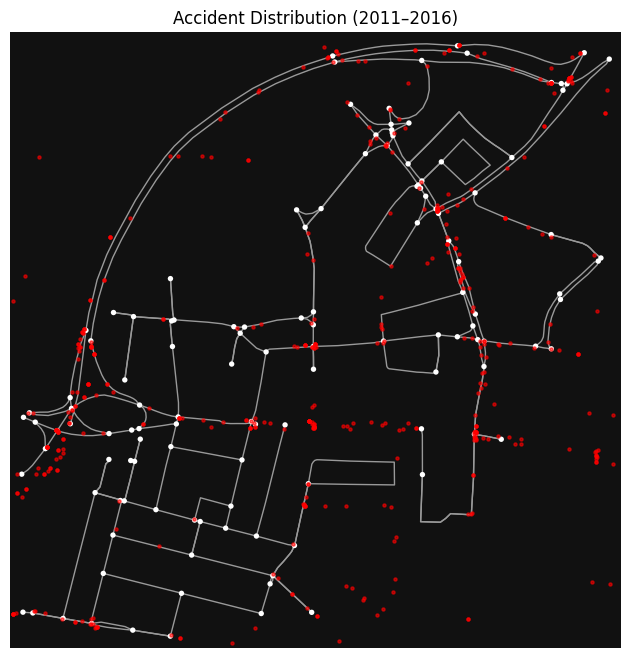

In [19]:
fig,ax=ox.plot_graph(G,show=False,close=False)
ax.scatter(area_df['Longitude'],area_df['Latitude'],c='red',s=5,alpha=0.6)
plt.title("Accident Distribution (2011–2016)")
plt.show()

Intersections (nodes) are represented by white circles/points while road segments (edges) are represented using white lines. Red points show the locations of accidents.

We can see from the plot that accidents are concentrated/clustered along specific roads and junctions, especially along major roads. Some accident points do not appear on the edges (floating points) because we plot the points using recorded accident locations while the road network representation is restricted to strictly driving roads (using OSMnx). This means those accidents could have happened along small side roads, parking lots or roads that OSMnx does not consider driveable.

<h3>Question 2: Investigate whether a high number of accidents on one road correlates with a high number on connecting roads. Calculate the k-function and the Moran's I values for the above spatial graph. What inferences can you draw from this analysis?

We need to investigate whether a high number of accidents on one road correlates with a high number on connecting roads. For this, we will use Moran's I and Ripley's K-function values.

But first, we need to calculate the number of accidents per road segment.
To do this, accident data (longitude, latitude) are first converted into spatial points and stored in a GeoDataFrame. The road network is then projected to an appropriate coordinate system, and its edges are extracted. The accident points are reprojected to match the network’s coordinate system and snapped to the nearest road segments, using the spaghetti library. For each accident, the nearest edge is assigned, and the number of accidents on each edge is counted and mapped onto the network. The edges without accidents are assigned a value of zero.

In [20]:
geometry=[Point(xy) for xy in zip(area_df['Longitude'],area_df['Latitude'])] #convert lat/lon data to spatial points
gdf_points=gpd.GeoDataFrame(area_df,geometry=geometry,crs="EPSG:4326") #points stored in GeoDataFRame

G_proj=ox.project_graph(G) #projected graph
edges=ox.graph_to_gdfs(G_proj,nodes=False) #road segments
gdf_points=gdf_points.to_crs(edges.crs)

#create network & snap points
ntw=spaghetti.Network(in_data=edges)
ntw.snapobservations(gdf_points,name='accidents') #snapping points

In [21]:
#nearest edge for each accident
area_df=area_df.copy()
edge_ids=ox.distance.nearest_edges(G_proj,X=gdf_points.geometry.x,Y=gdf_points.geometry.y) #edge ids of nearest edges for points

area_df['edge']=edge_ids

In [22]:
#accidents per edge
counts=area_df['edge'].value_counts()
edges['accidents']=edges.index.map(counts) #save accident counts for each edge
edges['accidents']=edges['accidents'].fillna(0) #put 0 where values missing

**Moran's I:**<br>Moran’s I is a measure of spatial autocorrelation, used to assess whether similar values occur near each other in space. We use it here to find whether roads with a high number of accidents tend to be located near other roads with similarly high number of accidents. To calculate this, we find the number of accidents per road and construct spatial weights using a k-nearest neighbours approach based on the centroids of road segments. This allows nearby roads to be considered as neighbours. Our global Moran’s I value, calculated using the Moran() function from the esda library, is given below:

In [23]:
#centroids of each road
edges['centroid']=edges.geometry.centroid
coords=[(point.x,point.y) for point in edges['centroid']]

#spatial weights (k-nearest neighbours)
W=libpysal.weights.KNN.from_array(coords,k=5) #consider 5 nearest neighbours
W.transform='R' #row-standardise weights

#accident values (per road)
acc=edges['accidents'].values

moran=Moran(acc,W)
print("Moran’s I:",moran.I)

Moran’s I: 0.21927246354683563


A positive Moran’s I indicates the presence of clustering. This means that roads with a high number of accidents tend to be connected to or located near other roads with high number of accidents, while roads with fewer accidents are located near similar roads.

**K-function:**<br>
The k_test function from pointpats library performs a global Ripley's K-function with statistical significance testing. It is used to analyse the distribution of point data and determine whether events are clustered, randomly distributed, or dispersed over different distance scales by comparing against simulations of complete spatial randomness. The p-values in the output are used to determine if the observed clustering is statistically significant. Here we apply it to the accident locations to examine whether accidents tend to occur close to each other.

In [24]:
pt_list=list(zip(area_df['Longitude'],area_df['Latitude']))
coords=np.array(pt_list)
result=k_test(coords)
print(result)

KtestResult(support=array([0.00000000e+00, 9.44904712e-05, 1.88980942e-04, 2.83471414e-04,
       3.77961885e-04, 4.72452356e-04, 5.66942827e-04, 6.61433299e-04,
       7.55923770e-04, 8.50414241e-04, 9.44904712e-04, 1.03939518e-03,
       1.13388565e-03, 1.22837613e-03, 1.32286660e-03, 1.41735707e-03,
       1.51184754e-03, 1.60633801e-03, 1.70082848e-03, 1.79531895e-03]), statistic=array([0.00000000e+00, 8.93912176e-07, 1.42716471e-06, 1.92470837e-06,
       2.57103901e-06, 3.14595190e-06, 3.66849178e-06, 4.28625532e-06,
       4.90044797e-06, 5.43131992e-06, 6.01694547e-06, 6.59066807e-06,
       7.23580841e-06, 8.27255609e-06, 8.98673359e-06, 9.71876553e-06,
       1.05948233e-05, 1.15970524e-05, 1.24457333e-05, 1.33265522e-05]), pvalue=array([0.    , 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001,
       0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001,
       0.0001, 0.0001, 0.0001, 0.0001]), simulations=None)


The very low p-values (approximately 0.0001) indicate that the observed accident distribution significantly deviates from a random pattern. In fact, accidents are strongly clustered, i.e. they tend to occur near other incidents. Thus, we have localised hotspots of accidents.

The Moran’s I and K-function values therefore indicate that roads with a high number of accidents tend to be connected to or located near other roads with high accident counts, showing that accidents are clustered rather than random.


<h3>Question 3. Investigate whether accidents happen nearer to intersections or partway along roads. Consider this as asking at what fraction of the road length away from the nearest intersection do accidents typically occur.

To investigate where accidents occur along roads, each accident location is snapped to the road network so each accident point lies on a valid road segment. For each snapped point, we project it onto the road geometry to find its position along the road. Then the distance to the nearest intersection is calculated and expressed as a fraction of the total road length. Finally, the average value of all those fractions will help us answer the question.

In [25]:
fracs=[]
pts=ntw.pointpatterns['accidents'] #accident points

#loop through each row of df containing road info, and accident points to match each accident to a road segment
road_n_pts=zip(area_df.iterrows(),pts.points.values())
for (i,row),p in road_n_pts:
    snapped_pt=Point(p['coordinates'])
    #corresponding road
    edge=row['edge']
    road=edges.loc[edge].geometry

    #position along road & total road length
    dist_along=road.project(snapped_pt)
    total_len=road.length

    #distance to nearest intersection
    dist_nearest_inter=min(dist_along, total_len-dist_along)

    fraction=dist_nearest_inter/total_len if total_len>0 else 0
    fracs.append(fraction)

area_df['fraction']=fracs
print("Average fraction of the road length away from the nearest intersection where accidents typically occur:",area_df['fraction'].mean())

Average fraction of the road length away from the nearest intersection where accidents typically occur: 0.16251592254514835


This value 0.1625 is closer to 0 (intersection) than 0.5 (middle of the road). This indicates that accidents typically occur closer to intersections (with an average position at about 16% of the road length from the nearest intersection) rather than partway along roads. However, since the value is not extremely close to zero, it suggests that accidents can occur along road segments as well. Overall, intersections appear to be more accident-prone areas.

<h2>Task C (Voronoi Diagrams)

Despite its accidents, the city of Leeds is ideal for organising marathons. The city mayor would like to organise a day of parallel, simultaneous marathons in different parts of the city. The mayor would like to maximise the participation of citizens by organising these marathons in diverse locations of the city, dividing the city into various areas (or “cells”) so that every person can join a marathon that is close to their home. Within each of these cells, a path of exactly 42 km is needed. Assuming that the mayor would like to organise N=4
simultaneous marathons:

For this task, we will use the walking network of the entire Leeds city instead of the driving network in the previous two tasks, as realistic marathon routes prefer pedestrian-friendly roads.

In [26]:
from scipy.spatial import Voronoi

In [27]:
#getting Leeds walking network
place="Leeds, UK"
G=ox.graph_from_place(place,network_type='walk')
G_proj=ox.project_graph(G)
nodes,edges=ox.graph_to_gdfs(G_proj)

print("Nodes:",len(G_proj.nodes))
print("Edges:",len(G_proj.edges))

Nodes: 96754
Edges: 251686


<h3>Question 1. Select the initial set of 4 cell seed points. For this, you can use several criteria, such as being far away from frequent accident roads, being close to public transport, being evenly spread, etc. (explain your choice in the report).

We divide the study area into 4 quadrants using the extreme coordinates of the road network. One seed point is placed at the centre of each quadrant to ensure an even spread across the city. This ensures that the initial Voronoi cells cover distinct areas, satisfying the Mayor's criterion: "The mayor would like to maximise the participation of citizens by organising these marathons in diverse locations of the city, dividing the city into various areas (or “cells”) so that every person can join a marathon that is close to their home."

In [28]:
minx,miny,maxx,maxy=edges.total_bounds

midx=(minx+maxx)/2
midy=(miny+maxy)/2
seed_points = [
    ((minx+midx)/2,(miny+midy)/2), #bottom-left
    ((minx+midx)/2,(midy+maxy)/2), #top-left
    ((midx+maxx)/2,(miny+midy)/2), #bottom-right
    ((midx+maxx)/2,(midy+maxy)/2) #top-right
]

print("The initial seed points are:",seed_points)

The initial seed points are: [(587317.0670026175, 5958279.530738832), (587317.0670026175, 5971841.421862807), (604175.1942256449, 5958279.530738832), (604175.1942256449, 5971841.421862807)]


The resulting seed points are expressed in a projected coordinate system (in metres), and the coordinates confirm that they are evenly distributed across the study area.

<h3>Question 2. Visualise the cells yield by your selection of seed points in a Voronoi diagram. What kind of Voronoi diagram (edge planar, node network, or edge points network) is most useful for this problem, and why?

<h4>Approach 1

First, the selected seed points are mapped onto the road network by converting each point to its nearest graph node. Then, for each seed node, the shortest path distances to all other nodes in the network are calculated using Dijkstra’s algorithm based on edge length. For every node, the nearest seed is identified by comparing its distances to all seeds and selecting the closest one. This process is extended to edges by checking the nearest seed for both end nodes of each edge and assigning the closest seed overall. Next, a unique colour is assigned to each seed, and edges are coloured based on the seed they are closest to, while seed nodes are highlighted in red (other nodes are highlighted in black).

This network-based Voronoi (from Week 5 lab) partitions the graph based on shortest path distance, resulting in edge-coloured regions that reflect real-world accessibility.

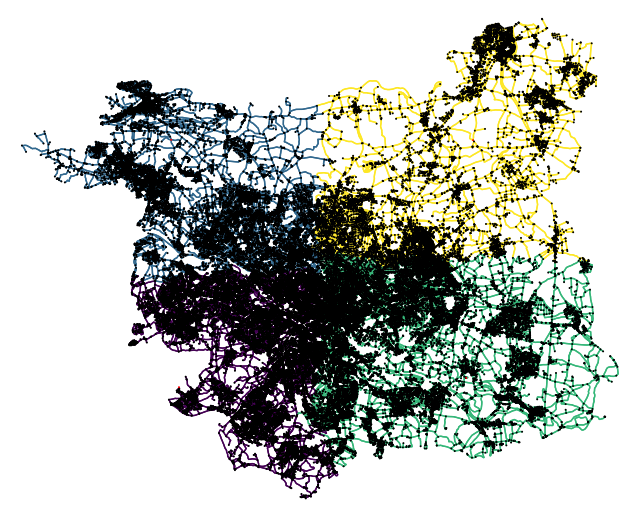

In [29]:
#converting seed points to nearest graph nodes
seeds=[]
for x,y in seed_points:
    nn=ox.distance.nearest_nodes(G_proj,x,y)
    seeds.append(nn)

NUMBER_OF_SEEDS=len(seeds)
all_nodes=list(G_proj.nodes)

#shortest path distances from each seed
distances={}
for seed in seeds:
    dist=nx.single_source_dijkstra_path_length(G_proj,seed,weight='length')
    distances[seed]=dist

def nearest_from_list(node_dists): #nearest nodes
    return sorted(node_dists,key=lambda x:x[1])[0] if node_dists else None

def nearest_seed(node):  #nearest seed for a node
    seed_dists=[]
    for s in seeds:
        if node in distances[s]:
            dist=distances[s][node]
            seed_dists.append((s,dist))
    return nearest_from_list(seed_dists)


def nearest_seed_for_edge(edge):  #nearest seed for each edge as edge has two ends
    nearest=[]
    # check first end of edge
    e1=nearest_seed(edge[0])
    if e1:
        nearest.append(e1)
    # check second end of edge
    e2=nearest_seed(edge[1])
    if e2:
        nearest.append(e2)
    return nearest_from_list(nearest)


colours=ox.plot.get_colors(NUMBER_OF_SEEDS)

def colour_seed(seed): #edge colour
    return colours[seeds.index(seed[0])]

edge_nearest_seeds=[nearest_seed_for_edge(edge) for edge in G_proj.edges]
edge_colours=[colour_seed(seed) if seed else 'k' for seed in edge_nearest_seeds]
node_colours=['red' if node in seeds else 'black' for node in all_nodes]

#plot
fig,ax=ox.plot_graph(G_proj,
    edge_color=edge_colours,node_color=node_colours,
    node_size=2,bgcolor='white',
    show=True,close=False
)

However, since we are visualising a whole city with a huge number of intersections, the resulting Voronoi diagram is extremely cluttered. Instead, we can try to use another interpretation of Voronoi diagram.

<h4>Approach 2

We will use the Voronoi function from scipy.spatial to generate the Voronoi diagram from spatial coordinates based on Euclidean distance from the seed point. Since we only have 4 symmetrically placed points, the resulting Voronoi regions are infinite (theoretically) which makes the use of different colours for different regions difficult. So we will add extra padding points outside the study area to force the Voronoi regions corresponding to the original seed points to become finite. After using both types of points to construct the diagram, we keep only the original seed points and clip the regions to the study area boundary. The road network is then overlaid on the diagram.

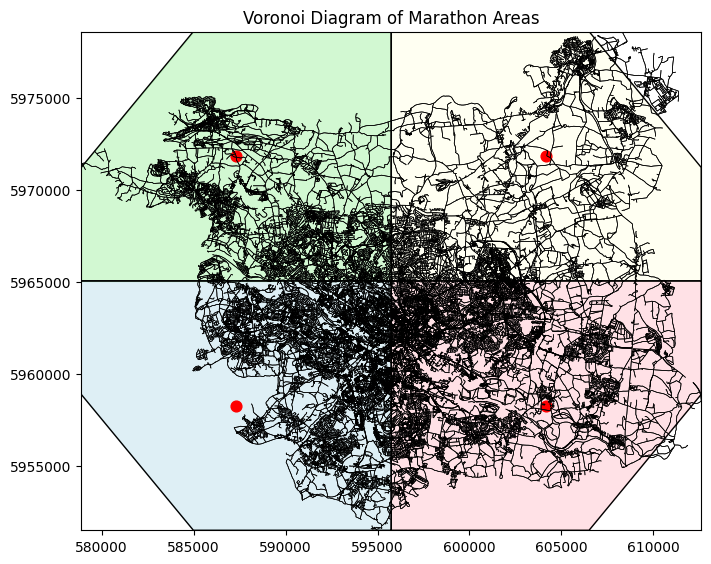

In [30]:
points=np.array(seed_points) #seeds
minx,miny,maxx,maxy=edges.total_bounds #extreme points

#extra padding points (to make regions finite)
padding=1000  #in meters
extra_points=np.array([
    [minx-padding,miny-padding],
    [minx-padding,maxy+padding],
    [maxx+padding,miny-padding],
    [maxx+padding,maxy+padding]
])
all_points=np.vstack([points,extra_points]) #seed+padding points

#Voronoi diagram using all points
vor=Voronoi(all_points)

fig,ax=plt.subplots(figsize=(8,8))
edges.plot(ax=ax,linewidth=0.5,color='black')

bbox=Polygon([(minx,miny),(minx,maxy),(maxx,maxy),(maxx,miny)])
colors=['lightblue','lightgreen','lightpink','lightyellow']
polygon_cells=[] #will use this in the later parts

#plotting only 4 original cells
for i in range(len(points)):
    reg_ind=vor.point_region[i]
    reg=vor.regions[reg_ind]

    if not reg or -1 in reg:
        continue

    poly=Polygon([vor.vertices[j] for j in reg])
    poly=poly.intersection(bbox)
    if not poly.is_empty:
        polygon_cells.append(poly)
        x,y=poly.exterior.xy
        ax.fill(x,y,alpha=0.4,color=colors[i])
        ax.plot(x,y,color='black',linewidth=1)

ax.scatter(points[:,0],points[:,1],color='red',s=60)
ax.set_aspect('equal')
ax.ticklabel_format(style='plain',useOffset=False)
ax.set_xlim(minx,maxx)
ax.set_ylim(miny,maxy)
plt.title("Voronoi Diagram of Marathon Areas")
plt.show()

This is significantly easier to interpret and also a cleaner representation to later visualise the marathon circuits in each cell. Also, we can see that although the method of construction is different, the division of road networks into 4 regions looks identical in both cases. So we will use this visualisation method for the rest of the task.
The different colours help differentiate between the 4 different Voronoi cells without overlap. The red circles represent the seed points.

The Voronoi regions don’t perfectly match the rectangular study area, so there are some triangular gaps near the edges. This happens because Voronoi diagrams are based on distance to the seed points and don’t follow the shape of the boundary. When we clip them to the study area, some small areas are left out, which is normal.

The edge points network Voronoi diagram considers distances along the entire road network, including both road segments and intersections, rather than relying solely on Euclidean distance or node-based distances. In contrast, edge planar Voronoi diagrams ignore the structure of the road network, and node-based Voronoi diagrams only consider intersections. Since marathon routes must follow the road network, edge points network Voronoi diagram is the most suitable for this problem.

<h3>Question 3. Find 2 or 3 cells for which you can find at least one path (or more, if possible) that is (a)approximately 42 km long, and (b)finishes at the same point where it starts. Visualise both the cells and the found paths.<br>
<br>
Question 4. Try to extend the previous step to all cells. Can you find at least one such a path for
every cell?

<h4>Approach 1

Here, we treat each Voronoi cell as a separate subgraph. Our aim is to find a ~42km path that starts and ends at the same point, for each cell. To start, we build a function path_length() that calculates the total length of a path by summing its edge lengths, and a function to get the extreme nodes within a cell (i.e. the nodes at the boundaries of the cell - topmost, bottommost, leftmost and rightmost). Such nodes are used as starting points as they can potentially produce longer routes spanning the entire cell. For each extreme node, we use the Dijkstra's shortest path algoritm to find distances to all other nodes in the cell and categorise them as either a mid node (10-20 km away) or a far node (20-35 km away). These distances are chosen so that when paths are combined to form a closed loop, the total path length can be ~42. Then, for each combination of nodes, we compute shortest paths from the start node to a mid node, from the mid node to a far node, and from the far node back to the start node. Finally, we concatenate these paths to form a closed loop, and choose the one closest to 42km out of all the valid loops. This process is repeated for all Voronoi cells. Note that here, even though there can be more than one possible path, we choose to get just one path closest to 42km.

In [31]:
#to calculate total length of a path
def total_path_length(G,path):
    len=0
    for u,v in zip(path[:-1],path[1:]):
        edge_data=list(G.get_edge_data(u,v).values())[0]
        len+=edge_data['length']
    return len

In [32]:
#to get the extreme nodes of a Voronoi cell
def cell_extreme_nodes(cell_nodes):
    coords=[(n,G_proj.nodes[n]['x'],G_proj.nodes[n]['y']) for n in cell_nodes]
    leftmost=min(coords,key=lambda x:x[1])[0]
    rightmost=max(coords,key=lambda x:x[1])[0]
    bottommost=min(coords,key=lambda x:x[2])[0]
    topmost=max(coords,key=lambda x:x[2])[0]

    return list(set([leftmost,rightmost,topmost,bottommost]))

In [33]:
#approach 1: combined shortest paths
def closed_path_42km(cell_polygon):
    cell_nodes=nodes[nodes.within(cell_polygon)].index.tolist()

    if len(cell_nodes)<10: #ignore the cells with less than 10 nodes as such a path would probably be impossible
        return None

    subgraph=G_proj.subgraph(cell_nodes).copy()
    extreme_nodes=cell_extreme_nodes(cell_nodes)
    best_loop=None
    best_diff=float('inf')

    for start in extreme_nodes: #from each extreme node, find mid nodes and far nodes based on shortest path distance
        try:
            lens=nx.single_source_dijkstra_path_length(subgraph,start,weight='length')
            mid_nodes=[n for n,d in lens.items() if 10000<=d<=20000]
            far_nodes=[n for n,d in lens.items() if 20000<=d<=35000]

            for a in mid_nodes[:20]:
                for b in far_nodes[:20]:
                    try:
                        path_starttomid=nx.shortest_path(subgraph,start,a,weight='length') #distance from start node to a middle node
                        path_midtofar=nx.shortest_path(subgraph,a,b,weight='length') #distance from the middle node to a far node
                        path_fartostart=nx.shortest_path(subgraph,b,start,weight='length') #distance from the far node back to the start node
                        loop=path_starttomid + path_midtofar[1:] + path_fartostart[1:] #add distances to get the loop length

                        if loop[0]!=loop[-1]: #check if first and last node of loop is the same
                            continue

                        length=total_path_length(subgraph,loop) #total path length for the loop

                        diff=abs(length-42000)
                        if diff<best_diff: #choose the best path, i.e. closest to 42km
                            best_diff=diff
                            best_loop=(loop,length)
                    except:
                        continue
        except:
            continue

    return best_loop

In [34]:
results=[]

for i in range(len(polygon_cells)): #path for each cell
    res=closed_path_42km(polygon_cells[i])

    if res: #if a path exists
        loop,length=res
        results.append((i,loop,length))
        print(f"Cell {i}: {length/1000:.2f} km")
    else:
        print(f"Cell {i}: No loop found")

Cell 0: 41.96 km
Cell 1: 41.87 km
Cell 2: 42.00 km
Cell 3: No loop found


Although this approach is relatively simple and computationally efficient, it comes with some limitations: Although individual fragments are shortest paths (i.e. no repetition of nodes or edges), the combined loop does not always guarantee a simple cycle, which is okay for a real situation as marathons do sometimes reuse certain road fragments. Moreover, it is heuristic-based and success highly depends on the distance ranges and size of subset we choose to explore for the mid and far nodes. It is also sensitive to the network structure.

Even after experimenting with different parameter values, we could not find a ~42km marathon circuit for Cell 3.

Let's visualise the paths we did find successfully.

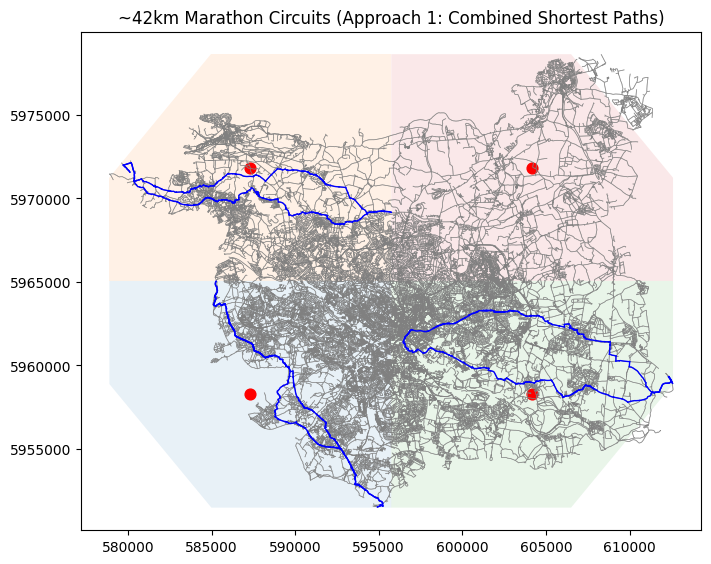

In [35]:
fig,ax=plt.subplots(figsize=(8,8))

#Voronoi cells
for poly in polygon_cells:
    x,y=poly.exterior.xy
    ax.fill(x,y,alpha=0.1)

#walking roads
edges.plot(ax=ax,color='gray',linewidth=0.5,alpha=0.7)

#closed paths we found
for cell_id,loop,length in results:
    for u,v in zip(loop[:-1],loop[1:]):
        if G_proj.has_edge(u,v):
            edge_data=list(G_proj.get_edge_data(u,v).values())[0]

            if 'geometry' in edge_data:
                xs,ys=edge_data['geometry'].xy
            else:
                xs=[G_proj.nodes[u]['x'],G_proj.nodes[v]['x']]
                ys=[G_proj.nodes[u]['y'],G_proj.nodes[v]['y']]

            ax.plot(xs,ys,color='blue',linewidth=1)

# seed points
s_points=np.array(seed_points)
ax.scatter(s_points[:,0],s_points[:,1],color='red',s=60)
ax.set_title("~42km Marathon Circuits (Approach 1: Combined Shortest Paths)")
ax.set_aspect('equal')
ax.ticklabel_format(style='plain',useOffset=False)
plt.show()

For all visualisations:
- Cell 0: Bottom-left
- Cell 1: Top-left
- Cell 2: Bottom-right
- Cell 3: Top-right

Each Voronoi cell is represented using a different colour. The closed ~42km marathon circuits are highlighted in blue, and the red circles represent the seed points. The road network is drawn using thinner grey lines with 70% opacity to reduce clutter and easily interpret the marathon paths.

Since we could not find a circuit for Cell 3 using this method, let's try to find a method that could help us find such a circuit for Cell 3 specifically.

<h4>Approach 2

In this method, we will try to directly identify the closed paths (cycles) within the road network of a cell. First we create a subgraph for each cell (in this case, Cell 3), and convert it from the original directed multigraph to a simple undirected graph (using nx.Graph()) to be able to detect cycles. Then, we use the cycle_basis() function from NetworkX to detect all the cycles in the graph. The total length of each cycle is then computed and only the cycles with length 41.5km-42.5km are kept. Since Cell 3 only has one such cycle, we will directly use it to visualise the path.

Cell 3 Path Length: 42.02 km


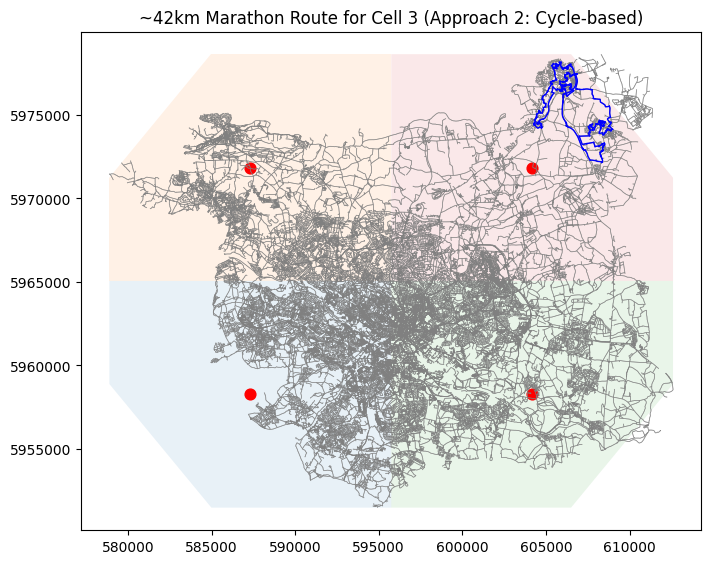

In [36]:
cell_nodes=nodes[nodes.within(polygon_cells[3])].index.tolist()
cell3=G_proj.subgraph(cell_nodes).copy()
G_un=nx.Graph(cell3)
cycles=nx.cycle_basis(G_un)

def cycle_length(cycle,G):
    length=0
    for i in range(len(cycle)):
        u=cycle[i]
        v=cycle[(i + 1) % len(cycle)]  #wrap around
        if G.has_edge(u,v):
            length+=G[u][v].get('length',0)
    return length

cycle_lens=[(cycle,cycle_length(cycle,G_un)) for cycle in cycles]
selected_cycles=[(cycle,length) for cycle,length in cycle_lens if 41500<=length<=42500]

for cycle,length in selected_cycles:
    print(f"Cell 3 Path Length: {length/1000:.2f} km")
    cycle_42=cycle


#visualisation
cycle_nodes=cycle_42
fig,ax=plt.subplots(figsize=(8,8))

#cells
for poly in polygon_cells:
    x,y=poly.exterior.xy
    ax.fill(x,y,alpha=0.1)

#roads
edges.plot(ax=ax,color='gray',linewidth=0.5,alpha=0.7)

#cycle
for u,v in zip(cycle_nodes,cycle_nodes[1:]+[cycle_nodes[0]]):
    if G_proj.has_edge(u,v):
        edge_data=list(G_proj.get_edge_data(u,v).values())[0]

        if 'geometry' in edge_data:
            xs,ys=edge_data['geometry'].xy
        else:
            xs=[G_proj.nodes[u]['x'],G_proj.nodes[v]['x']]
            ys=[G_proj.nodes[u]['y'],G_proj.nodes[v]['y']]

        ax.plot(xs,ys,color='blue',linewidth=1)

s_points=np.array(seed_points)
ax.scatter(s_points[:,0],s_points[:,1],color='red',s=60)
ax.set_title("~42km Marathon Route for Cell 3 (Approach 2: Cycle-based)")
ax.set_aspect('equal')
ax.ticklabel_format(style='plain',useOffset=False)
plt.show()

We use the same visualisation techniques like in the previous approach.

Now, the question is, does this method also work for the other cells?<br>
For each cell, we may either have no paths (cycles) or more than one path, so we need to handle both situations. In case of more than one path, we will select the path closest to 42km in length.

In [37]:
def find_cycles(cell_polygon):
    cell_nodes=nodes[nodes.within(cell_polygon)].index.tolist()
    G_cell=G_proj.subgraph(cell_nodes).copy()
    G_un=nx.Graph(G_cell)
    cycles=nx.cycle_basis(G_un)

    def cycle_length(cycle):
        length=0
        for i in range(len(cycle)):
            u=cycle[i]
            v=cycle[(i+1)%len(cycle)]
            if G_un.has_edge(u,v):
                length+=G_un[u][v].get('length',0)
        return length

    cycle_lengths=[(cycle,cycle_length(cycle)) for cycle in cycles]
    selected_cycles=[(cycle,length)for cycle,length in cycle_lengths if 41500<=length<=42500]
    return selected_cycles

#if cycles exist, selecting classes closest to 42km
best_cycles={}
for i in range(len(polygon_cells)):
    cycles=find_cycles(polygon_cells[i])

    if cycles:
        cycle,length=min(cycles,key=lambda x:abs(x[1]-42000))
        best_cycles[i]=(cycle,length)
        print(f"Cell {i}: {length/1000:.2f} km")
    else:
        print(f"Cell {i}: No cycle found")

Cell 0: 41.98 km
Cell 1: No cycle found
Cell 2: 41.99 km
Cell 3: 42.02 km


We can see that this method finds paths for all cells except Cell 1. Here too, we choose to display the path closest to 42km, although more than one cycle is available for some cells. <br>Let's visualise these paths using the same visualisation techniques:

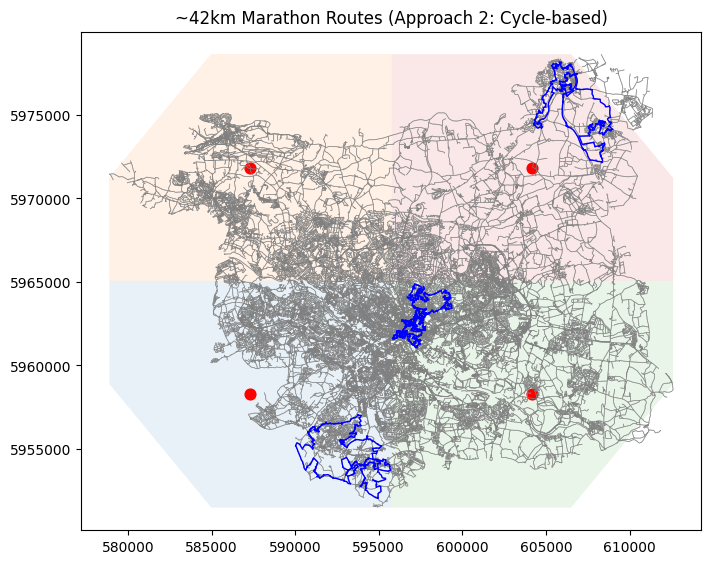

In [38]:
fig,ax=plt.subplots(figsize=(8,8))

for poly in polygon_cells:
    x,y=poly.exterior.xy
    ax.fill(x,y,alpha=0.1)

edges.plot(ax=ax,color='gray',linewidth=0.5,alpha=0.7)

#cycles
for cell_id,(cycle,length) in best_cycles.items():
    for u,v in zip(cycle,cycle[1:]+[cycle[0]]):
        if G_proj.has_edge(u,v):
            edge_data=list(G_proj.get_edge_data(u,v).values())[0]
            if 'geometry' in edge_data:
                xs,ys=edge_data['geometry'].xy
            else:
                xs=[G_proj.nodes[u]['x'],G_proj.nodes[v]['x']]
                ys=[G_proj.nodes[u]['y'],G_proj.nodes[v]['y']]
            ax.plot(xs,ys,color='blue',linewidth=1)

points=np.array(seed_points)
ax.scatter(points[:,0],points[:,1],color='red',s=60)
plt.title("~42km Marathon Routes (Approach 2: Cycle-based)")
ax.set_aspect('equal')
ax.ticklabel_format(style='plain',useOffset=False)
plt.show()

This is a non-heuristic approach that guarantees a true cycle (no node/edge repetition) and successfully finds a 42km closed path in Cell 3. However, it comes with certain limitations too: The cycle_basis() function depends heavily on the structure of the network and therefore success is not always guaranteed (like in Cell 1). Morever, converting a directed multigraph into a simple undirected graph can slightly change the real road network.

Overall, we can see that it is possible to find ~42km closed paths for all regions (cells) using more than one approach. This makes sense as, being a NP-hard problem, it is difficult to find one single method that works for all cells in all situations and network structures.

<h3>Question 5. If for steps 3-4 there were cells with no such path, what different options could you consider increasing the number of cells that include such paths? (Hint: think about the number and location of seed points; the size of the area under consideration; etc.) Choose one of such options, repeat steps 3-4, and report the results you obtain, explaining your reasoning.

 We could find ~42km paths for all cells using a combination of heuristic shortest paths and graph cycle-based methods. Therefore, we don't need to do much for this question. However, we could consider future work where we optimise factors like the number and location of seed points, the size of area under consideration, etc. to improve the availability of such paths, or even come up with a universal algorithm that works across all network structures and constraints, thus solving a problem that is considered NP-Hard otherwise.